In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import  ColumnTransformer

In [3]:
df = pd.read_csv("titanic_toy.csv")

In [4]:
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [5]:
df.isnull().sum()

Age         177
Fare         45
Family        0
Survived      0
dtype: int64

In [11]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [12]:
X_train,X_test,Y_train,Y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [15]:
X_train['Age_99'] = X_train['Age'].fillna(99)
X_train['Age_minus1'] = X_train['Age'].fillna(-1)

X_train['Fare_99'] = X_train['Fare'].fillna(999)
X_train['Fare_minus1'] = X_train['Fare'].fillna(-1)

In [16]:
print("Original Age variable variance : ",X_train['Age'].var())
print("Age Varianve after 99 imputation : " , X_train['Age_99'].var())
print("Age Variance after mean imputation : " , X_train['Age_minus1'].var())

print("\n")

print("Original Fare variable variance : ",X_train['Fare'].var())
print("Fare Varianve after 99 imputation : " , X_train['Fare_99'].var())
print("Fare Variance after mean imputation : " , X_train['Fare_minus1'].var())


Original Age variable variance :  210.2517072477435
Age Varianve after 99 imputation :  932.9665366701432
Age Variance after mean imputation :  315.9955036260055


Original Fare variable variance :  2761.0314349486343
Fare Varianve after 99 imputation :  47525.470595360035
Fare Variance after mean imputation :  2675.2394049177024


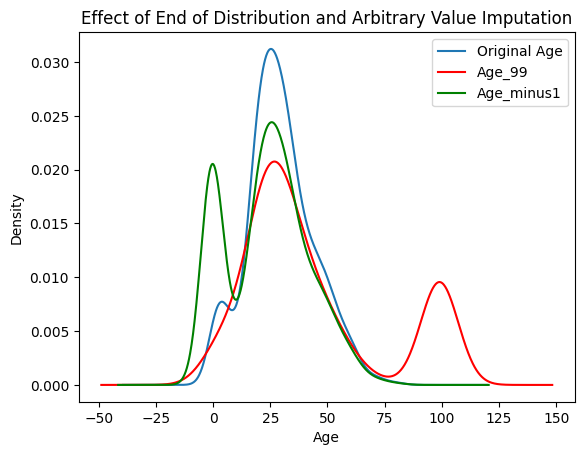

In [18]:
fig = plt.figure()
ax = fig.add_subplot(111)

# Original distribution
X_train['Age'].plot(kind='kde', ax=ax, label='Original Age')

# Imputed with 99th percentile
X_train['Age_99'].plot(kind='kde', ax=ax, color='red', label='Age_99')

# Imputed with -1
X_train['Age_minus1'].plot(kind='kde', ax=ax, color='green', label='Age_minus1')

ax.legend(loc='best')

plt.title('Effect of End of Distribution and Arbitrary Value Imputation')
plt.xlabel('Age')
plt.ylabel('Density')
plt.show()

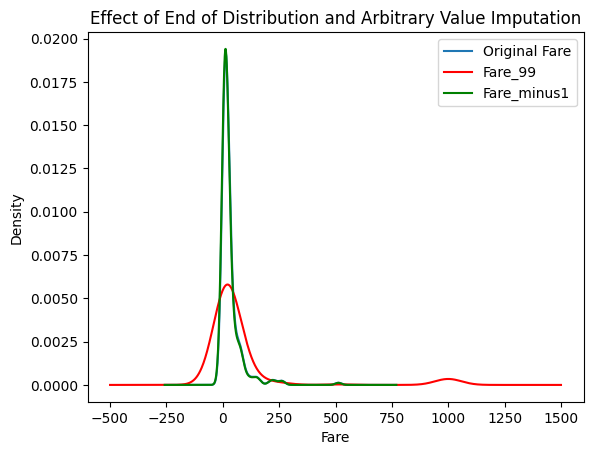

In [19]:
fig = plt.figure()
ax = fig.add_subplot(111)

# Original distribution
X_train['Fare'].plot(kind='kde', ax=ax, label='Original Fare')

# Imputed with 99th percentile
X_train['Fare_99'].plot(kind='kde', ax=ax, color='red', label='Fare_99')

# Imputed with -1
X_train['Fare_minus1'].plot(kind='kde', ax=ax, color='green', label='Fare_minus1')

ax.legend(loc='best')

plt.title('Effect of End of Distribution and Arbitrary Value Imputation')
plt.xlabel('Fare')
plt.ylabel('Density')
plt.show()

In [20]:
X_train.cov()

,Age,Fare,Family,Age_99,Age_minus1,Fare_999,Fare_minus1,Fare_99
Age,210.251707,75.481375,-6.993325,210.251707,210.251707,130.495777,69.137162,130.495777
Fare,75.481375,2761.031435,18.599163,-111.965046,135.785804,2761.031435,2761.031435,2761.031435
Family,-6.993325,18.599163,2.830892,-6.941982,-5.034556,16.878492,17.684447,16.878492
Age_99,210.251707,-111.965046,-6.941982,932.966537,-166.460682,-255.051165,-101.137070,-255.051165
Age_minus1,210.251707,135.785804,-5.034556,-166.460682,315.995504,262.712284,124.270305,262.712284
Fare_999,130.495777,2761.031435,16.878492,-255.051165,262.712284,47525.470595,1063.944817,47525.470595
Fare_minus1,69.137162,2761.031435,17.684447,-101.137070,124.270305,1063.944817,2675.239405,1063.944817
Fare_99,130.495777,2761.031435,16.878492,-255.051165,262.712284,47525.470595,1063.944817,47525.470595


In [21]:
X_train.corr()

,Age,Fare,Family,Age_99,Age_minus1,Fare_999,Fare_minus1,Fare_99
Age,1.000000,0.091482,-0.319651,1.000000,1.000000,0.039967,0.085422,0.039967
Fare,0.091482,1.000000,0.207193,-0.069365,0.145071,1.000000,1.000000,1.000000
Family,-0.319651,0.207193,1.000000,-0.135079,-0.168329,0.046016,0.203212,0.046016
Age_99,1.000000,-0.069365,-0.135079,1.000000,-0.306576,-0.038303,-0.064017,-0.038303
Age_minus1,1.000000,0.145071,-0.168329,-0.306576,1.000000,0.067792,0.135159,0.067792
Fare_999,0.039967,1.000000,0.046016,-0.038303,0.067792,1.000000,0.094357,1.000000
Fare_minus1,0.085422,1.000000,0.203212,-0.064017,0.135159,0.094357,1.000000,0.094357
Fare_99,0.039967,1.000000,0.046016,-0.038303,0.067792,1.000000,0.094357,1.000000


## Using Sklearn

In [32]:
X_train,X_test,Y_train,Y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [38]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

imputer1 = SimpleImputer(strategy='constant', fill_value=99)
imputer2 = SimpleImputer(strategy='constant', fill_value=999)

trf = ColumnTransformer([
    ('imputer1', imputer1, ['Age']),
    ('imputer2', imputer2, ['Fare'])
], remainder='passthrough')

trf.fit(X_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('imputer1', ...), ('imputer2', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``featu

In [40]:
trf.named_transformers_['imputer1'].statistics_

array([99], dtype=object)

In [41]:
trf.named_transformers_['imputer2'].statistics_

array([999], dtype=object)

In [42]:
X_train = trf.transform(X_train)
X_test = trf.transform(X_test)

In [43]:
X_train

array([[ 40.    ,  27.7208,   0.    ],
       [  4.    ,  16.7   ,   2.    ],
       [ 47.    ,   9.    ,   0.    ],
       ...,
       [ 71.    ,  49.5042,   0.    ],
       [ 99.    , 221.7792,   0.    ],
       [ 99.    ,  25.925 ,   0.    ]], shape=(712, 3))